# Практическая работа №2

**Тема:** дискриминативные интеллектуальные алгоритмы.

**Датасет:** UCI Heart Disease из практической работы №1.

**Задача:** бинарная классификация: предсказать наличие сердечно-сосудистого заболевания по медицинским признакам пациента.

## 1. Постановка задачи

В первой практической работе был подготовлен набор данных Heart Disease: объединены четыре источника, обработаны пропуски, скрытые аномалии и категориальные признаки.

В этой работе использую ту же предметную область и решаю дискриминативную задачу классификации. По уточнению преподавателя оставляю логистическую регрессию как базовую модель и добавляю:

- `RandomForestClassifier` как бэггинг-модель;
- `GradientBoostingClassifier` как бустинговую модель;
- ансамбль `VotingClassifier` из трёх моделей;
- взвешенный ансамбль, где больший вес получает модель с лучшим F1 на кросс-валидации обучающей выборки.

Также сравниваю обучение на сырых и предобработанных данных, чтобы оценить вклад предобработки.

In [1]:
from pathlib import Path
import os
import warnings

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "lab1").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

LAB1_DIR = PROJECT_ROOT / "lab1"
LAB2_DIR = PROJECT_ROOT / "lab2"
DATA_DIR = LAB1_DIR / "heart+disease"

os.environ.setdefault("MPLCONFIGDIR", str(Path("/private/tmp") / "mathprog_lab2_cache" / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
TARGET_LABELS = ["нет болезни", "есть болезнь"]

Matplotlib is building the font cache; this may take a moment.


## 2. Загрузка данных

Использую четыре processed-файла из UCI Heart Disease. Целевая переменная `num` переводится в бинарный формат: `0` — болезни нет, `1` — болезнь есть.

In [2]:
columns = [
    "age",       # возраст
    "sex",       # пол: 1 - male, 0 - female
    "cp",        # тип боли в груди
    "trestbps",  # давление в покое
    "chol",      # холестерин
    "fbs",       # сахар натощак > 120 mg/dl
    "restecg",   # ЭКГ в покое
    "thalach",   # максимальная ЧСС
    "exang",     # стенокардия при нагрузке
    "oldpeak",   # депрессия ST
    "slope",     # наклон сегмента ST
    "ca",        # число крупных сосудов
    "thal",      # результат thal-теста
    "num",       # исходная целевая переменная
]

source_files = {
    "Cleveland": "processed.cleveland.data",
    "Hungarian": "processed.hungarian.data",
    "Switzerland": "processed.switzerland.data",
    "Long Beach VA": "processed.va.data",
}

frames = []
for source, filename in source_files.items():
    part = pd.read_csv(
        DATA_DIR / filename,
        header=None,
        names=columns,
        na_values="?",
    )
    part["source"] = source
    frames.append(part)

raw = pd.concat(frames, ignore_index=True)
raw["target"] = (raw["num"] > 0).astype(int)

print(f"Размер объединённого набора: {raw.shape[0]} строк, {raw.shape[1]} колонок")
display(raw.head())
display(raw.groupby("source").size().rename("rows").to_frame())

Размер объединённого набора: 920 строк, 16 колонок


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,Cleveland,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland,0


,rows
source,
Cleveland,303
Hungarian,294
Long Beach VA,200
Switzerland,123


## 3. Анализ исходных данных

Перед обучением проверяю баланс классов, пропуски, скрытые аномалии и корреляции основных числовых признаков.

,count,percent
target,,
есть болезнь,509,55.33
нет болезни,411,44.67


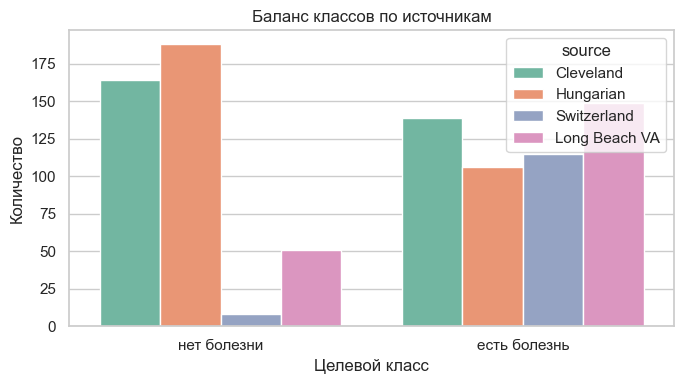

In [3]:
target_distribution = (
    raw["target"]
    .map({0: "нет болезни", 1: "есть болезнь"})
    .value_counts()
    .rename_axis("target")
    .to_frame("count")
)
target_distribution["percent"] = (target_distribution["count"] / len(raw) * 100).round(2)
display(target_distribution)

plt.figure(figsize=(7, 4))
sns.countplot(data=raw, x="target", hue="source")
plt.title("Баланс классов по источникам")
plt.xlabel("Целевой класс")
plt.ylabel("Количество")
plt.xticks([0, 1], TARGET_LABELS)
plt.tight_layout()
plt.show()

,missing_count,missing_percent
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
thalach,55,5.98
exang,55,5.98
chol,30,3.26
restecg,2,0.22


,zero_count
trestbps,1
chol,172
thalach,0


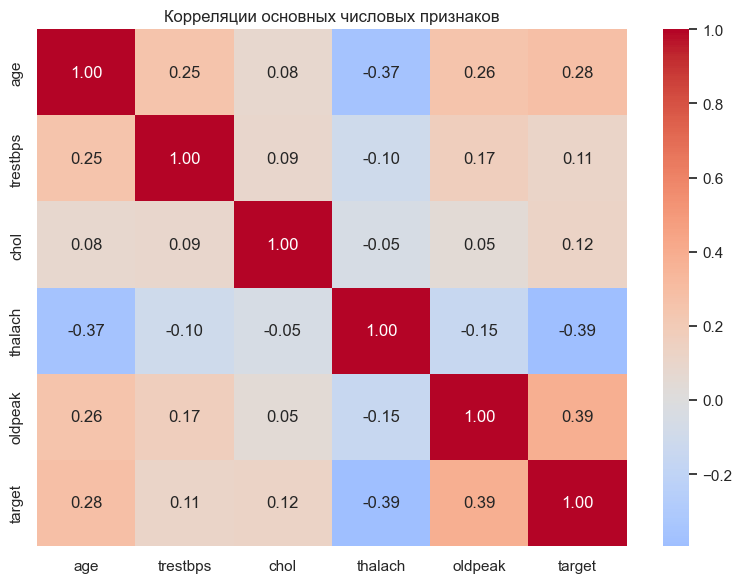

In [4]:
feature_cols = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal"
]

quality = (
    raw[feature_cols]
    .isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: (x["missing_count"] / len(raw) * 100).round(2))
    .sort_values("missing_percent", ascending=False)
)

zero_checks = pd.DataFrame({
    "zero_count": {
        col: int((raw[col] == 0).sum())
        for col in ["trestbps", "chol", "thalach"]
    }
})

display(quality)
display(zero_checks)

analysis_df = raw.drop_duplicates().copy()
analysis_df.loc[analysis_df["chol"] == 0, "chol"] = np.nan
analysis_df.loc[analysis_df["trestbps"] == 0, "trestbps"] = np.nan

main_numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "target"]
corr = analysis_df[main_numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляции основных числовых признаков")
plt.tight_layout()
plt.show()

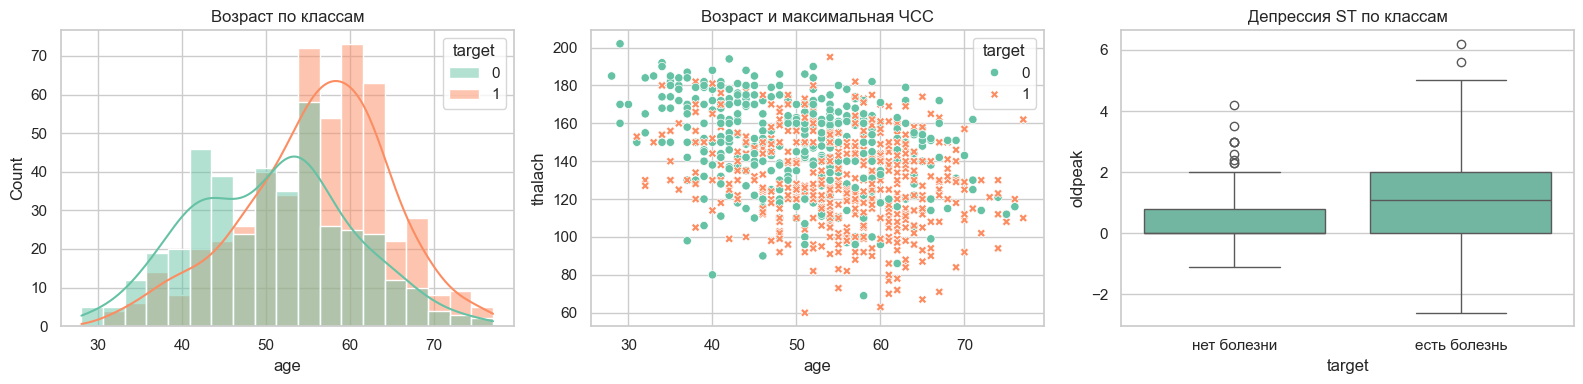

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=analysis_df, x="age", hue="target", kde=True, ax=axes[0])
axes[0].set_title("Возраст по классам")

sns.scatterplot(data=analysis_df, x="age", y="thalach", hue="target", style="target", ax=axes[1])
axes[1].set_title("Возраст и максимальная ЧСС")

sns.boxplot(data=analysis_df, x="target", y="oldpeak", ax=axes[2])
axes[2].set_title("Депрессия ST по классам")
axes[2].set_xticklabels(TARGET_LABELS)

for ax in axes:
    ax.set_xlabel(ax.get_xlabel())
    ax.set_ylabel(ax.get_ylabel())

plt.tight_layout()
plt.show()

Вывод по качеству данных:

- строки с `?` преобразованы в `NaN`;
- `ca` имеет слишком большую долю пропусков, поэтому в предобработанной версии будет удалён;
- `chol = 0` и `trestbps = 0` являются скрытыми пропусками;
- классы достаточно близки по размеру, но для линейной модели оставляю `class_weight="balanced"`.

## 4. Подготовка сырых и предобработанных данных

Для сравнения делаю две версии признакового пространства.

**Сырые данные:** удаляю дубликаты, строки с пропусками и строки со скрытыми аномалиями. Кодированные категориальные признаки остаются как числа.

**Предобработанные данные:** повторяю подход из практической работы №1: удаление дубликатов, замена скрытых пропусков, удаление `ca`, флаги пропусков, медиана/мода, стандартизация числовых признаков и one-hot encoding категориальных.

In [6]:
df = raw.drop_duplicates().reset_index(drop=True)
df["target"] = (df["num"] > 0).astype(int)

df.loc[df["chol"] == 0, "chol"] = np.nan
df.loc[df["trestbps"] == 0, "trestbps"] = np.nan

raw_model_data = df[feature_cols + ["target"]].dropna().copy()
X_raw = raw_model_data[feature_cols].astype(float)
y_raw = raw_model_data["target"].astype(int)

print(f"Сырые данные после удаления пропусков и аномалий: {X_raw.shape[0]} строк, {X_raw.shape[1]} признаков")
display(y_raw.value_counts().sort_index().rename({0: "нет болезни", 1: "есть болезнь"}).to_frame("count"))

Сырые данные после удаления пропусков и аномалий: 299 строк, 13 признаков


,count
target,
нет болезни,160
есть болезнь,139


In [7]:
missing_rate = df[feature_cols].isna().mean().sort_values(ascending=False)
high_missing_cols = missing_rate[missing_rate > 0.60].index.tolist()
model_features = [col for col in feature_cols if col not in high_missing_cols]

cols_with_missing = [col for col in model_features if df[col].isna().any()]
for col in cols_with_missing:
    df[f"{col}_was_missing"] = df[col].isna().astype(int)

indicator_features = [f"{col}_was_missing" for col in cols_with_missing]
numeric_features = [col for col in ["age", "trestbps", "chol", "thalach", "oldpeak"] if col in model_features]
categorical_features = [col for col in ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"] if col in model_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("missing_flag", "passthrough", indicator_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

preprocessor.set_output(transform="pandas")
X_preprocessed = preprocessor.fit_transform(df[model_features + indicator_features])
y_preprocessed = df["target"].astype(int)

print("Удалённые признаки из-за высокой доли пропусков:", high_missing_cols)
print("Флаги пропусков:", indicator_features)
print(f"Предобработанные данные: {X_preprocessed.shape[0]} строк, {X_preprocessed.shape[1]} признаков")
display(y_preprocessed.value_counts().sort_index().rename({0: "нет болезни", 1: "есть болезнь"}).to_frame("count"))
display(X_preprocessed.head())

Удалённые признаки из-за высокой доли пропусков: ['ca']
Флаги пропусков: ['trestbps_was_missing', 'chol_was_missing', 'fbs_was_missing', 'restecg_was_missing', 'thalach_was_missing', 'exang_was_missing', 'oldpeak_was_missing', 'slope_was_missing', 'thal_was_missing']
Предобработанные данные: 918 строк, 33 признаков


,count
target,
нет болезни,410
есть болезнь,508


,age,trestbps,chol,thalach,oldpeak,sex_0.0,sex_1.0,cp_1.0,cp_2.0,cp_3.0,cp_4.0,fbs_0.0,fbs_1.0,restecg_0.0,restecg_1.0,restecg_2.0,exang_0.0,exang_1.0,slope_1.0,slope_2.0,slope_3.0,thal_3.0,thal_6.0,thal_7.0,trestbps_was_missing,chol_was_missing,fbs_was_missing,restecg_was_missing,thalach_was_missing,exang_was_missing,oldpeak_was_missing,slope_was_missing,thal_was_missing
0,1.006537,0.717747,-0.238774,0.489681,1.365834,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,0,0,0,0,0,0,0,0
1,1.430829,1.555037,0.784507,-1.180980,0.609600,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,0
2,1.430829,-0.677737,-0.316003,-0.345649,1.649422,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0,0,0,0,0,0,0,0,0
3,-1.751359,-0.119543,0.089448,1.961454,2.500185,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,0
4,-1.327067,-0.119543,-0.798682,1.364789,0.515071,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,0


## 5. Модели и метрики

Использую одинаковый протокол оценки для обеих версий данных:

- стратифицированное разделение на train/test в пропорции 75/25;
- кросс-валидация на train-части для подбора весов ансамбля;
- итоговые метрики на test-части: `accuracy`, `precision`, `recall`, `F1`, `ROC-AUC`;
- матрицы ошибок для моделей на предобработанных данных.

In [8]:
def make_base_models():
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
    }


def calculate_rank_weights(cv_f1):
    ordered = sorted(cv_f1.items(), key=lambda item: item[1])
    return {name: rank + 1 for rank, (name, _) in enumerate(ordered)}


def make_ensembles(base_models, rank_weights):
    estimators = [
        ("logreg", clone(base_models["Logistic Regression"])),
        ("rf", clone(base_models["Random Forest"])),
        ("gb", clone(base_models["Gradient Boosting"])),
    ]
    weights = [
        rank_weights["Logistic Regression"],
        rank_weights["Random Forest"],
        rank_weights["Gradient Boosting"],
    ]
    return {
        "Voting Ensemble": VotingClassifier(
            estimators=estimators,
            voting="soft",
            n_jobs=1,
        ),
        "Weighted Voting Ensemble": VotingClassifier(
            estimators=[
                ("logreg", clone(base_models["Logistic Regression"])),
                ("rf", clone(base_models["Random Forest"])),
                ("gb", clone(base_models["Gradient Boosting"])),
            ],
            voting="soft",
            weights=weights,
            n_jobs=1,
        ),
    }


def evaluate_dataset(X, y, dataset_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    base_models = make_base_models()
    min_class_size = int(y_train.value_counts().min())
    n_splits = max(3, min(5, min_class_size))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    cv_f1 = {}
    for model_name, model in base_models.items():
        scores = cross_val_score(
            clone(model),
            X_train,
            y_train,
            cv=cv,
            scoring="f1",
        )
        cv_f1[model_name] = float(scores.mean())

    rank_weights = calculate_rank_weights(cv_f1)
    models = {**base_models, **make_ensembles(base_models, rank_weights)}

    rows = []
    fitted_models = {}
    predictions = {}

    for model_name, model in models.items():
        fitted = clone(model).fit(X_train, y_train)
        y_pred = fitted.predict(X_test)
        y_score = fitted.predict_proba(X_test)[:, 1]

        rows.append(
            {
                "Dataset": dataset_name,
                "Model": model_name,
                "Rows": len(y),
                "Train rows": len(y_train),
                "Test rows": len(y_test),
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred, zero_division=0),
                "F1": f1_score(y_test, y_pred, zero_division=0),
                "ROC-AUC": roc_auc_score(y_test, y_score),
            }
        )
        fitted_models[model_name] = fitted
        predictions[model_name] = y_pred

    cv_rows = [
        {
            "Dataset": dataset_name,
            "Model": model_name,
            "CV F1": cv_score,
            "Voting weight": rank_weights[model_name],
        }
        for model_name, cv_score in cv_f1.items()
    ]

    details = {
        "X_test": X_test,
        "y_test": y_test,
        "fitted_models": fitted_models,
        "predictions": predictions,
        "rank_weights": rank_weights,
    }

    return pd.DataFrame(rows), pd.DataFrame(cv_rows), details

In [9]:
raw_results, raw_cv_weights, raw_details = evaluate_dataset(X_raw, y_raw, "Сырые данные")
preprocessed_results, preprocessed_cv_weights, preprocessed_details = evaluate_dataset(
    X_preprocessed,
    y_preprocessed,
    "Предобработанные данные",
)

results = pd.concat([raw_results, preprocessed_results], ignore_index=True)
cv_weights = pd.concat([raw_cv_weights, preprocessed_cv_weights], ignore_index=True)

dataset_order = ["Сырые данные", "Предобработанные данные"]
model_order = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting",
    "Voting Ensemble",
    "Weighted Voting Ensemble",
]

results["Dataset"] = pd.Categorical(results["Dataset"], categories=dataset_order, ordered=True)
results["Model"] = pd.Categorical(results["Model"], categories=model_order, ordered=True)
cv_weights["Dataset"] = pd.Categorical(cv_weights["Dataset"], categories=dataset_order, ordered=True)
cv_weights["Model"] = pd.Categorical(cv_weights["Model"], categories=model_order, ordered=True)

display(cv_weights.sort_values(["Dataset", "Voting weight"]).round(4))

,Dataset,Model,CV F1,Voting weight
2,Сырые данные,Gradient Boosting,0.8058,1
0,Сырые данные,Logistic Regression,0.8082,2
1,Сырые данные,Random Forest,0.8154,3
5,Предобработанные данные,Gradient Boosting,0.8140,1
3,Предобработанные данные,Logistic Regression,0.8208,2
4,Предобработанные данные,Random Forest,0.8248,3


Веса для взвешенного голосования считаются только по train-части. Это важно: тестовая выборка не используется при выборе весов, поэтому итоговая оценка остаётся честной.

In [10]:
results_sorted = results.sort_values(["Dataset", "F1"], ascending=[True, False]).reset_index(drop=True)
display(results_sorted.round(4))

metrics_path = LAB2_DIR / "lab2_heart_disease_model_metrics.csv"
results_sorted.to_csv(metrics_path, index=False)
print(f"Метрики сохранены: {metrics_path}")

,Dataset,Model,Rows,Train rows,Test rows,Accuracy,Precision,Recall,F1,ROC-AUC
0,Сырые данные,Logistic Regression,299,224,75,0.8267,0.8438,0.7714,0.8060,0.9321
1,Сырые данные,Weighted Voting Ensemble,299,224,75,0.8133,0.8621,0.7143,0.7812,0.9286
2,Сырые данные,Random Forest,299,224,75,0.8000,0.8333,0.7143,0.7692,0.9143
3,Сырые данные,Voting Ensemble,299,224,75,0.8000,0.8571,0.6857,0.7619,0.9271
4,Сырые данные,Gradient Boosting,299,224,75,0.7733,0.8462,0.6286,0.7213,0.8557
5,Предобработанные данные,Voting Ensemble,918,688,230,0.8565,0.8507,0.8976,0.8736,0.9134
6,Предобработанные данные,Weighted Voting Ensemble,918,688,230,0.8522,0.8550,0.8819,0.8682,0.9135
7,Предобработанные данные,Logistic Regression,918,688,230,0.8478,0.8538,0.8740,0.8638,0.9179
8,Предобработанные данные,Random Forest,918,688,230,0.8435,0.8473,0.8740,0.8605,0.9067
9,Предобработанные данные,Gradient Boosting,918,688,230,0.8304,0.8188,0.8898,0.8528,0.9028


Метрики сохранены: /Users/gdj4/mirea_labs/mathprog/lab2/lab2_heart_disease_model_metrics.csv


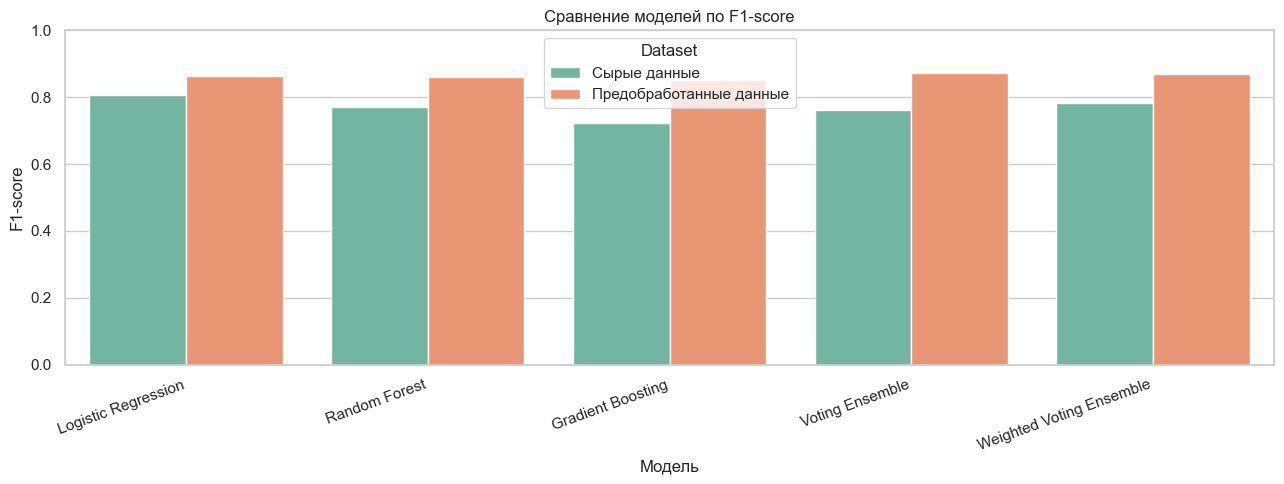

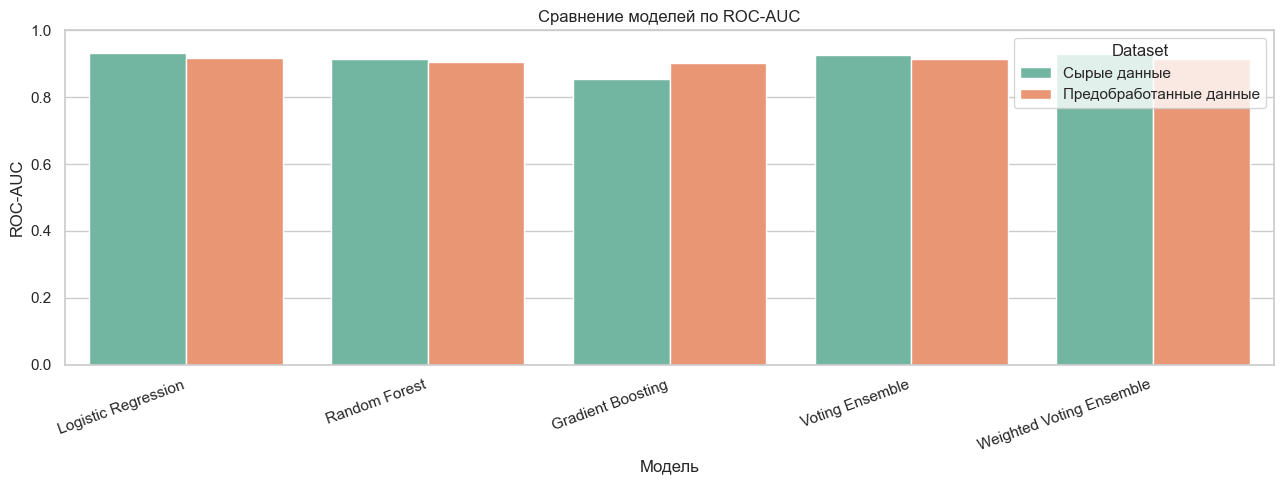

In [11]:
plt.figure(figsize=(13, 5))
sns.barplot(
    data=results_sorted,
    x="Model",
    y="F1",
    hue="Dataset",
)
plt.title("Сравнение моделей по F1-score")
plt.xlabel("Модель")
plt.ylabel("F1-score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 5))
sns.barplot(
    data=results_sorted,
    x="Model",
    y="ROC-AUC",
    hue="Dataset",
)
plt.title("Сравнение моделей по ROC-AUC")
plt.xlabel("Модель")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [12]:
comparison = (
    results
    .pivot(index="Model", columns="Dataset", values="F1")
    .loc[model_order]
    .assign(
        **{
            "F1 gain after preprocessing": lambda x: x["Предобработанные данные"] - x["Сырые данные"]
        }
    )
)
display(comparison.round(4))

Dataset,Сырые данные,Предобработанные данные,F1 gain after preprocessing
Model,,,
Logistic Regression,0.8060,0.8638,0.0578
Random Forest,0.7692,0.8605,0.0912
Gradient Boosting,0.7213,0.8528,0.1315
Voting Ensemble,0.7619,0.8736,0.1117
Weighted Voting Ensemble,0.7812,0.8682,0.0870


## 6. Матрицы ошибок

Ниже показаны матрицы ошибок для всех моделей на предобработанной версии данных, потому что именно она использует больше данных и даёт лучший итоговый результат.

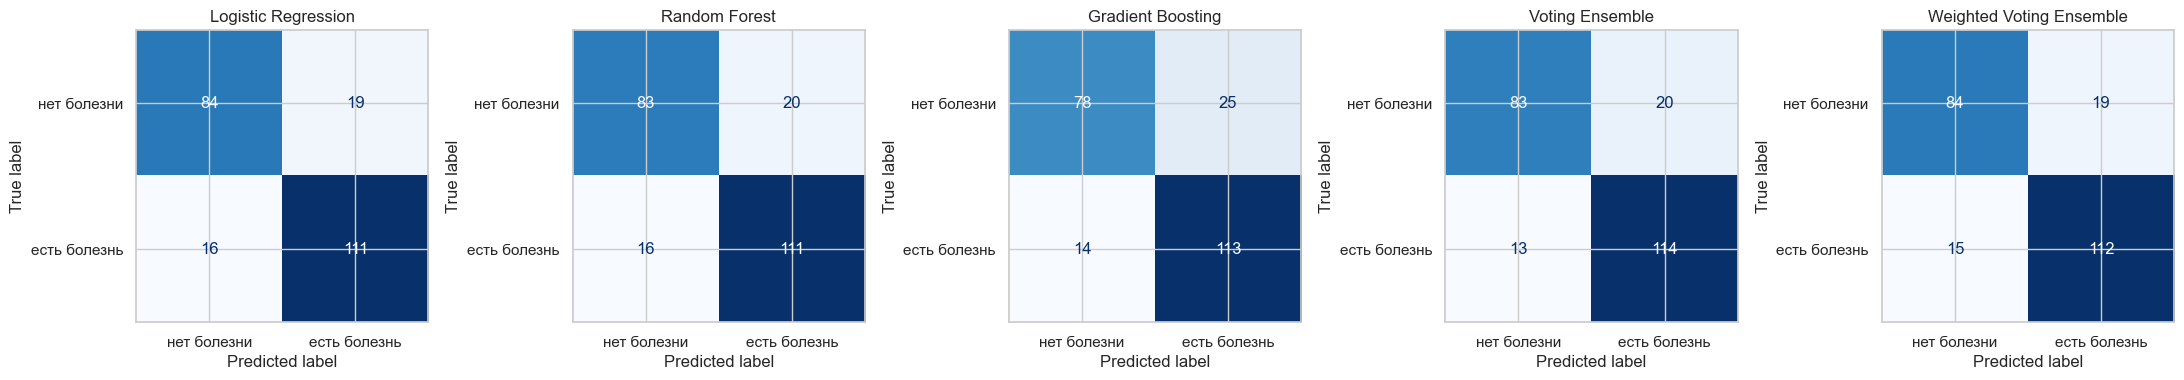

In [13]:
fig, axes = plt.subplots(1, len(model_order), figsize=(22, 4))

for ax, model_name in zip(axes, model_order):
    ConfusionMatrixDisplay.from_predictions(
        preprocessed_details["y_test"],
        preprocessed_details["predictions"][model_name],
        display_labels=TARGET_LABELS,
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

In [14]:
best_row = results.sort_values(["F1", "ROC-AUC"], ascending=False).iloc[0]
print(
    "Лучшая модель:",
    best_row["Model"],
    "| данные:",
    best_row["Dataset"],
    "| F1:",
    round(float(best_row["F1"]), 4),
    "| Accuracy:",
    round(float(best_row["Accuracy"]), 4),
    "| ROC-AUC:",
    round(float(best_row["ROC-AUC"]), 4),
)

print("\nClassification report для лучшей модели на предобработанных данных:")
best_preprocessed_model = results[results["Dataset"] == "Предобработанные данные"].sort_values(
    ["F1", "ROC-AUC"],
    ascending=False,
).iloc[0]["Model"]
print("Модель:", best_preprocessed_model)
print(
    classification_report(
        preprocessed_details["y_test"],
        preprocessed_details["predictions"][best_preprocessed_model],
        target_names=TARGET_LABELS,
    )
)

Лучшая модель: Voting Ensemble | данные: Предобработанные данные | F1: 0.8736 | Accuracy: 0.8565 | ROC-AUC: 0.9134

Classification report для лучшей модели на предобработанных данных:
Модель: Voting Ensemble
              precision    recall  f1-score   support

 нет болезни       0.86      0.81      0.83       103
есть болезнь       0.85      0.90      0.87       127

    accuracy                           0.86       230
   macro avg       0.86      0.85      0.85       230
weighted avg       0.86      0.86      0.86       230



## 7. Вывод

Логистическая регрессия оставлена как базовая модель. На предобработанных данных она показала заметно лучший результат, чем на сырых: F1 вырос примерно с `0.806` до `0.864`. Это связано с тем, что после предобработки модель использует не только строки без пропусков, но и почти весь очищенный набор данных, а категориальные признаки представлены через one-hot encoding.

Случайный лес и градиентный бустинг также обучены отдельно. Лес оказался устойчивым к шуму и дал качество, близкое к логистической регрессии. Бустинг показал сопоставимый, но немного более низкий F1 на тестовой выборке.

Лучший итоговый результат на фиксированном разбиении `random_state=42` дал ансамбль `VotingClassifier` на предобработанных данных: F1 около `0.874`, accuracy около `0.857`, ROC-AUC около `0.913`. Взвешенное голосование также проверено, но в этом запуске оно не улучшило обычное soft-voting, потому что базовые модели имеют близкое качество и дополнительный вес случайного леса слегка смещает ответы ансамбля.

Итог: предобработка из практической работы №1 улучшила качество классификации, а ансамбль из логистической регрессии, случайного леса и бустинга дал лучший баланс precision/recall среди проверенных вариантов.